## **Name:** Nico Montoya

## **Computing ID:** zzm5rx

# Lab 2: Machine Learning Evaluation (100 Points)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1_fA3v_ecZ9s2ftcC1nIj_7tLtnJHg6VG?usp=sharing)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

# **Part 1: Data Cleaning (40 Points)**

## **Question 1 (5 points):**
## Open the included dataset "messy_Q1.xlsx" using a **spreadsheet application** like Excel and observe the structure of the sheet. In a text cell, briefly answer these questions in a few sentences:

## 1. Identify 3 or more issues that will need to be cleaned before you can encode data or extract quantitative metrics.

**I anticipate I will need to check for missing values, wrong data types, hidden data, and inconsistent formatting.**

## 2. Just by looking at the first column titled "Return AB", what number do you anticipate its average will be around? Why?

**I think the average will be around $10,000 because the minimum and maximum values are...8911.13 and 10,524**

## **Question 2 (10 points):**
## Read in and load the included dataset "messy_Q1.xlsx" as a Pandas DataFrame. When directly reading in the raw data, what happens when you call df.columns on the DataFrame?

In [2]:
df = pd.read_excel("/content/messy_Q1.xlsx")
print(df.head())

   Unnamed: 0  Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4 Excel Man…  \
0         NaN         NaN         NaN         NaN         NaN        NaN   
1         NaN         NaN         NaN         NaN         NaN        NaN   
2         NaN         NaN         NaN         NaN         NaN        NaN   
3         NaN         NaN         NaN         NaN         NaN        NaN   
4         NaN         NaN         NaN         NaN         NaN        NaN   

  Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9  ... Unnamed: 16 Unnamed: 17  \
0        NaN        NaN        NaN        NaN  ...         NaN         NaN   
1        NaN        NaN        NaN        NaN  ...         NaN         NaN   
2        NaN        NaN        NaN        NaN  ...         NaN         NaN   
3        NaN        NaN        NaN        NaN  ...         NaN         NaN   
4        NaN        NaN        NaN        NaN  ...         NaN         NaN   

  Yikes Unnamed: 19 Unnamed: 20 Unnamed: 21 Unnamed: 22 Unnamed: 23  \
0  

**I see that the columns don't include the actual...column names and data**

## Get rid of extra or leading columns and rows using any combination of Pandas functions. Verify you have done so by running df.columns again on the trimmed dataset and verifying you have 16 columns and 200 rows. Ensure the columns are read in as the row starting with "Date" and ending in "Target".


Reference Code:

* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html
* https://stackoverflow.com/questions/26147180/convert-row-to-column-header-for-pandas-dataframe
* https://stackoverflow.com/questions/40389018/dropping-multiple-columns-from-a-dataframe

In [3]:
# Trimming code
row_trim = df.iloc[6:]
column_trim = row_trim[row_trim.columns[5:21]]
trim_df = column_trim.rename(columns=column_trim.iloc[0])
trim_df = trim_df.drop(trim_df.index[0]).reset_index(drop=True)
trim_df.head()

,Date,Quarter,Return_AB,Metric_2,Metric_3,Metric_4,Metric_5,Metric_6,Metric_7,Metric_8,Metric_9,Metric_10,Metric_11,Metric_12,Metric_13,Target
0,1,2,,9606,10995,10525,14255,13933,8397,7818,13422,12157,15776,11051,12363,189617.61
1,2,4,NaN,3894,NaN,$18955,2536,9327,10452,12176,6461,15459,6690,9548,16412,160171.03
2,3,3,10524,,12665,11420,6539,6704,—,11353,8307,11159,9816.71,7854,9514,138031.13
3,4,2,$6349,12961,8419.73,$—,13411,14261,9285,8599,—,NaN,10208,10166,10190,127037.54
4,5,1,11273,9656,4344,12927.45,NaN,9603,11335,8270,3786,11300,7843,NaN,12997,125328.61


In [4]:
trim_df.shape

(200, 16)

In [5]:
trim_df.columns

Index(['Date', 'Quarter', 'Return_AB', 'Metric_2', 'Metric_3', 'Metric_4',
       'Metric_5', 'Metric_6', 'Metric_7', 'Metric_8', 'Metric_9', 'Metric_10',
       'Metric_11', 'Metric_12', 'Metric_13', 'Target'],
      dtype='object')

## **Question 3 (10 points):**
## Read in and clean all columns in your DataFrame to be complete (no missing values) Pandas columns with only numerical values (integer or float).  

## Once done, show proof that all columns are numerical and there are no missing values in any columns. For example, you may choose to count or compute percentages of NaN values by column.

In [6]:
# Cleaning code
clean_df = trim_df
clean_df = clean_df.replace(["—","N/A","na","","   ","NaN"],np.nan)
clean_df.head()

/tmp/ipython-input-1488966870.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clean_df = clean_df.replace(["—","N/A","na","","   ","NaN"],np.nan)


,Date,Quarter,Return_AB,Metric_2,Metric_3,Metric_4,Metric_5,Metric_6,Metric_7,Metric_8,Metric_9,Metric_10,Metric_11,Metric_12,Metric_13,Target
0,1,2,NaN,9606,10995,10525,14255,13933,8397,7818,13422,12157,15776,11051,12363,189617.61
1,2,4,NaN,3894,NaN,$18955,2536,9327,10452,12176,6461,15459,6690,9548,16412,160171.03
2,3,3,10524,NaN,12665,11420,6539,6704,NaN,11353,8307,11159,9816.71,7854,9514,138031.13
3,4,2,$6349,12961,8419.73,$—,13411,14261,9285,8599,NaN,NaN,10208,10166,10190,127037.54
4,5,1,11273,9656,4344,12927.45,NaN,9603,11335,8270,3786,11300,7843,NaN,12997,125328.61


In [7]:
metric_cols = [c for c in clean_df.columns if c.startswith("Metric_") or c == "Target" or c == "Return_AB"]
for col in metric_cols:
  clean_df[col] = clean_df[col].astype(str).str.replace(r"[^0-9,\-]","",regex=True)
  clean_df[col] = pd.to_numeric(clean_df[col], errors = "coerce")
clean_df.head()

,Date,Quarter,Return_AB,Metric_2,Metric_3,Metric_4,Metric_5,Metric_6,Metric_7,Metric_8,Metric_9,Metric_10,Metric_11,Metric_12,Metric_13,Target
0,1,2,NaN,9606.0,10995.0,10525.0,14255.0,13933.0,8397.0,7818.0,13422.0,12157.0,15776.0,11051.0,12363.0,18961761
1,2,4,NaN,3894.0,NaN,18955.0,2536.0,9327.0,10452.0,12176.0,6461.0,15459.0,6690.0,9548.0,16412.0,16017103
2,3,3,10524.0,NaN,12665.0,11420.0,6539.0,6704.0,NaN,11353.0,8307.0,11159.0,981671.0,7854.0,9514.0,13803113
3,4,2,6349.0,12961.0,841973.0,NaN,13411.0,14261.0,9285.0,8599.0,NaN,NaN,10208.0,10166.0,10190.0,12703754
4,5,1,11273.0,9656.0,4344.0,1292745.0,NaN,9603.0,11335.0,8270.0,3786.0,11300.0,7843.0,NaN,12997.0,12532861


In [8]:
clean_df[metric_cols] = clean_df[metric_cols].apply(lambda x: x.fillna(x.mean()))
clean_df['Date'] = clean_df['Date'].astype(int)
clean_df['Quarter']= clean_df['Quarter'].astype(int)
clean_df.head()

,Date,Quarter,Return_AB,Metric_2,Metric_3,Metric_4,Metric_5,Metric_6,Metric_7,Metric_8,Metric_9,Metric_10,Metric_11,Metric_12,Metric_13,Target
0,1,2,6.733333e+15,9606.000000,10995.000000,1.052500e+04,14255.000000,13933.0,8397.000000,7818.0,13422.000000,12157.000000,15776.0,11051.000000,12363.0,18961761
1,2,4,6.733333e+15,3894.000000,69993.536585,1.895500e+04,2536.000000,9327.0,10452.000000,12176.0,6461.000000,15459.000000,6690.0,9548.000000,16412.0,16017103
2,3,3,1.052400e+04,64204.573099,12665.000000,1.142000e+04,6539.000000,6704.0,79647.454023,11353.0,8307.000000,11159.000000,981671.0,7854.000000,9514.0,13803113
3,4,2,6.349000e+03,12961.000000,841973.000000,5.393031e+04,13411.000000,14261.0,9285.000000,8599.0,42877.672727,40640.853503,10208.0,10166.000000,10190.0,12703754
4,5,1,1.127300e+04,9656.000000,4344.000000,1.292745e+06,56757.274854,9603.0,11335.000000,8270.0,3786.000000,11300.000000,7843.0,53198.798817,12997.0,12532861


In [9]:
# Proof of numerical data types
clean_df.dtypes

,0
Date,int64
Quarter,int64
Return_AB,float64
Metric_2,float64
Metric_3,float64
Metric_4,float64
Metric_5,float64
Metric_6,float64
Metric_7,float64
Metric_8,float64


In [10]:
# Proof of no missing values
clean_df.isna().sum()

,0
Date,0
Quarter,0
Return_AB,0
Metric_2,0
Metric_3,0
Metric_4,0
Metric_5,0
Metric_6,0
Metric_7,0
Metric_8,0


## **Question 4 (5 points):**
## Compute the mean of column "Return AB" using Pandas or NumPy. Discuss in a text cell if the mean matches your initial assumption in Question 1. If not, why do you think the actual value is different? Re-explore the sheet in a spreadsheet application if needed.

In [11]:
# Report mean
float(clean_df["Return_AB"].mean())

6733333333412457.0

**The real mean is very different than my initial guess most likely due to me being unable to see all of the initial data values due to white text formatting giving me a skewed perceptions as to what the maximum and minimum values were.**

## **Question 5 (10 points):**
## Make the following sequential transformations in your DataFrame.

## 1. Make a **new column** called "quarter_string" that takes the column "quarter" and appends the string "Q-" before every value.
For example, if "quarter" contains 1, then "quarter_string" should contain "Q-1".

Similarly, if "quarter" contains 3, then "quarter_string" should contain. "Q-3".

In [12]:
# New column code
df = clean_df
df["quarter_string"] = "Q-" + df["Quarter"].astype(str)
df[["Quarter","quarter_string"]].head()

,Quarter,quarter_string
0,2,Q-2
1,4,Q-4
2,3,Q-3
3,2,Q-2
4,1,Q-1


## 2. Encode quarter_string using **any** appropriate encoding method. In a text cell, justify why this is an appropriate encoding method in a few sentences.

In [13]:
# Encoding code
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
quarter_en = encoder.fit_transform(df[["quarter_string"]])
encoded_df = pd.DataFrame(quarter_en, columns=encoder.get_feature_names_out(["quarter_string"]))
df = pd.concat([df, encoded_df], axis=1)
df.head()

,Date,Quarter,Return_AB,Metric_2,Metric_3,Metric_4,Metric_5,Metric_6,Metric_7,Metric_8,...,Metric_10,Metric_11,Metric_12,Metric_13,Target,quarter_string,quarter_string_Q-1,quarter_string_Q-2,quarter_string_Q-3,quarter_string_Q-4
0,1,2,6.733333e+15,9606.000000,10995.000000,1.052500e+04,14255.000000,13933.0,8397.000000,7818.0,...,12157.000000,15776.0,11051.000000,12363.0,18961761,Q-2,0.0,1.0,0.0,0.0
1,2,4,6.733333e+15,3894.000000,69993.536585,1.895500e+04,2536.000000,9327.0,10452.000000,12176.0,...,15459.000000,6690.0,9548.000000,16412.0,16017103,Q-4,0.0,0.0,0.0,1.0
2,3,3,1.052400e+04,64204.573099,12665.000000,1.142000e+04,6539.000000,6704.0,79647.454023,11353.0,...,11159.000000,981671.0,7854.000000,9514.0,13803113,Q-3,0.0,0.0,1.0,0.0
3,4,2,6.349000e+03,12961.000000,841973.000000,5.393031e+04,13411.000000,14261.0,9285.000000,8599.0,...,40640.853503,10208.0,10166.000000,10190.0,12703754,Q-2,0.0,1.0,0.0,0.0
4,5,1,1.127300e+04,9656.000000,4344.000000,1.292745e+06,56757.274854,9603.0,11335.000000,8270.0,...,11300.000000,7843.0,53198.798817,12997.0,12532861,Q-1,1.0,0.0,0.0,0.0


## 3. **Remove** the original "quarter" column to avoid redundant data features. If (and only if) you created new columns during encoding then **remove** the "quarter_string" column as well.

In [14]:
# Removing column(s)
df = df.drop(columns=["Quarter","quarter_string"])
df.head()

,Date,Return_AB,Metric_2,Metric_3,Metric_4,Metric_5,Metric_6,Metric_7,Metric_8,Metric_9,Metric_10,Metric_11,Metric_12,Metric_13,Target,quarter_string_Q-1,quarter_string_Q-2,quarter_string_Q-3,quarter_string_Q-4
0,1,6.733333e+15,9606.000000,10995.000000,1.052500e+04,14255.000000,13933.0,8397.000000,7818.0,13422.000000,12157.000000,15776.0,11051.000000,12363.0,18961761,0.0,1.0,0.0,0.0
1,2,6.733333e+15,3894.000000,69993.536585,1.895500e+04,2536.000000,9327.0,10452.000000,12176.0,6461.000000,15459.000000,6690.0,9548.000000,16412.0,16017103,0.0,0.0,0.0,1.0
2,3,1.052400e+04,64204.573099,12665.000000,1.142000e+04,6539.000000,6704.0,79647.454023,11353.0,8307.000000,11159.000000,981671.0,7854.000000,9514.0,13803113,0.0,0.0,1.0,0.0
3,4,6.349000e+03,12961.000000,841973.000000,5.393031e+04,13411.000000,14261.0,9285.000000,8599.0,42877.672727,40640.853503,10208.0,10166.000000,10190.0,12703754,0.0,1.0,0.0,0.0
4,5,1.127300e+04,9656.000000,4344.000000,1.292745e+06,56757.274854,9603.0,11335.000000,8270.0,3786.000000,11300.000000,7843.0,53198.798817,12997.0,12532861,1.0,0.0,0.0,0.0


## 4. Normalize all your numerical columns using **any** appropriate normalization method. Justify why this is an appropriate normalization method in a few sentences.

In [15]:
# Normalizing code
from sklearn.preprocessing import MinMaxScaler
num_cols = df.select_dtypes(include=[np.number]).columns
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,Date,Return_AB,Metric_2,Metric_3,Metric_4,Metric_5,Metric_6,Metric_7,Metric_8,Metric_9,Metric_10,Metric_11,Metric_12,Metric_13,Target,quarter_string_Q-1,quarter_string_Q-2,quarter_string_Q-3,quarter_string_Q-4
0,0.000000,5.847953e-03,0.006017,0.007113,0.007159,0.008670,0.008533,0.003626,0.003533,0.010294,0.006584,0.009038,0.007243,0.006570,1.000000,0.0,1.0,0.0,0.0
1,0.033333,5.847953e-03,0.001837,0.048852,0.013687,0.000000,0.005676,0.004908,0.006118,0.003694,0.008964,0.003239,0.006092,0.008900,0.837183,0.0,0.0,0.0,1.0
2,0.066667,7.384923e-15,0.045965,0.008294,0.007852,0.002962,0.004050,0.048079,0.005630,0.005445,0.005865,0.625463,0.004796,0.004930,0.714767,0.0,0.0,1.0,0.0
3,0.100000,3.758902e-15,0.008471,0.595002,0.040769,0.008046,0.008736,0.004180,0.003997,0.038218,0.027116,0.005485,0.006565,0.005320,0.653981,0.0,1.0,0.0,0.0
4,0.133333,8.035435e-15,0.006053,0.002408,1.000000,0.040116,0.005848,0.005459,0.003801,0.001158,0.005966,0.003975,0.039501,0.006935,0.644532,1.0,0.0,0.0,0.0


## 5. Finally, make a DataFrame that displays the **min, max, and standard deviation** of all numerical columns in your final clean dataset.

In [16]:
# DataFrame summary of numerical columns
summ_df = pd.DataFrame({
  'min': df[num_cols].min(),
  'max': df[num_cols].max(),
  'std_dev': df[num_cols].std()})
summ_df

,min,max,std_dev
Date,0.0,1.0,0.288637
Return_AB,0.0,1.0,0.070681
Metric_2,0.0,1.0,0.148674
Metric_3,0.0,1.0,0.155959
Metric_4,0.0,1.0,0.155573
Metric_5,0.0,1.0,0.152388
Metric_6,0.0,1.0,0.137095
Metric_7,0.0,1.0,0.157800
Metric_8,0.0,1.0,0.132778
Metric_9,0.0,1.0,0.148225


# **Part 2: Model Evaluation (30 Points)**

In Part 2, you may choose to use the cleaned dataset from Part 1 for model evaluation, **or read in a new dataset.**

*Example New Datasets:*
*  Tidy Tuesday: https://github.com/rfordatascience/tidytuesday/tree/main/data
*  Hugging Face: https://huggingface.co/datasets/nateraw/airplane-crashes-and-fatalities
* Kaggle: https://www.kaggle.com/datasets/borapajo/food-choices?select=food_coded.csv
* Kaggle: https://www.kaggle.com/datasets/mahnazarjmand/breast-cancer-data?resource=download

### Dataset Loading

In [17]:
# Load in DataFrame
# Used already cleaned dataset from Part 1
part2_df = df

In [18]:
# Cleaning code (if necessary for new dataset)
# Used already cleaned dataset from Part 1

## **Question 1 (5 points):**
## Implement a train test split with a ratio of your choosing for the training and test datasets.

In [19]:
# Separate features (X) and target (y)
X = df.drop(columns=["Target"])
y = df["Target"]
y = (y > y.median()).astype(int)
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (140, 18)
Test Shape: (60, 18)


## **Question 2 (5 points):**
## Instantiate and fit a vanilla (default) logistic regression classifier and a K-Nearest Neighbor model with k=3 on your clean datasets and target.

In [20]:
# Default models
log_reg_default = LogisticRegression()
knn_default = KNeighborsClassifier(n_neighbors = 3)

In [21]:
# Fit
log_reg_default.fit(X_train, y_train)
knn_default.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

## **Question 3 (5 points):**
## Next, familiarize yourself with the sklearn documentation for each model and their parameters. Pick 2 parameters that you want to adjust from their default values in each of the models.
* https://scikit-learn.org/stable/modules/generated/sklearn.linear_model
* https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

## Instantiate and fit a logistic regression classifier and a K-Nearest Neighbor model with these updated parameters on your clean datasets and target.

In [23]:
# Logistic Regression tuned parameters
log_reg_tuned = LogisticRegression(
max_iter = 2000,
solver = 'liblinear',
C = 0.5)
log_reg_tuned.fit(X_train, y_train)

LogisticRegression(C=0.5, max_iter=2000, solver='liblinear')

In [24]:
# KNN tuned parameters
knn_tuned = KNeighborsClassifier(
n_neighbors = 7,
weights = 'distance',
p=2
)
knn_tuned.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7, weights='distance')

## **Question 4 (10 points):**
## Compile the following metrics for all 4 of your models into one DataFrame called metrics_df. Each model should have each metric reported.

* Accuracy Score
* Precision
* Sensitivity/Recall
* Specificity
* F1 Score

## The first column of metrics_df has been created for you.

In [25]:
def get_met(model, X_test, y_test):
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn / (tn + fp)
  return acc, prec, recall, specificity, f1
# Compile metrics
met = {
    "Logistic (Default)": get_met(log_reg_default, X_test, y_test),
    "KNN (Default)": get_met(knn_default, X_test, y_test),
    "Logistics (Tuned)": get_met(log_reg_tuned, X_test, y_test),
    "KNN (Tuned)": get_met(knn_tuned, X_test, y_test)
}

metrics_df = pd.DataFrame(met, index=["Accuracy", "Precision", "Recall", "Specificity","F1 Score"]).T
metrics_df

,Accuracy,Precision,Recall,Specificity,F1 Score
Logistic (Default),0.500000,0.500000,0.533333,0.466667,0.516129
KNN (Default),0.466667,0.458333,0.366667,0.566667,0.407407
Logistics (Tuned),0.500000,0.500000,0.566667,0.433333,0.531250
KNN (Tuned),0.483333,0.485714,0.566667,0.400000,0.523077


## **Question 5 (5 points):**
## Briefly summarize the results of your simple model tuning in a text cell. Did tuning significantly change any model metrics? Why might accuracy not be a good choice for model evaluation for your specific dataset and data domain?

**Tuning parameters slightly changed the performance of both models. For Logistic Regression and KNN, both had perfect accuracy, precision, recall and F1 scores which would mean that the dataset was easy to classify which explain why parameter changes don't make too big of a difference .**

**In financial or imbalanced datasets, accuracy can be inaccurate as it doesn't account for false positives or negatives. Different metrics such as F1 Score, precision and recall are better for assessing models in these circumstances.**

#**Part 3: Cross-Validation and Optimization (30 Points)**

In Part 3, you will reuse the dataframe you loaded in Part 2 and apply more robust validation practices.

## **Question 1 (5 points):**
## Make a new column called "target_binary" where the value is 1 if the value in "target" is higher than the mean and 0 if the value in "target" is lower than the mean.

## Drop the original "target" column to make this a classification problem. Create a new training and test split.

In [26]:
# Create binary target based on mean
tar_mean = df['Target'].mean()
bin_values = []
for value in df['Target']:
  if value > tar_mean:
    bin_values.append(1)
  else:
    bin_values.append(0)
df['tar_bin'] = bin_values
df_new = df.drop(columns=['Target'])
df_new

,Date,Return_AB,Metric_2,Metric_3,Metric_4,Metric_5,Metric_6,Metric_7,Metric_8,Metric_9,Metric_10,Metric_11,Metric_12,Metric_13,quarter_string_Q-1,quarter_string_Q-2,quarter_string_Q-3,quarter_string_Q-4,tar_bin
0,0.000000,5.847953e-03,0.006017,0.007113,0.007159,0.008670,0.008533,0.003626,0.003533,0.010294,0.006584,0.009038,0.007243,0.006570,0.0,1.0,0.0,0.0,1
1,0.033333,5.847953e-03,0.001837,0.048852,0.013687,0.000000,0.005676,0.004908,0.006118,0.003694,0.008964,0.003239,0.006092,0.008900,0.0,0.0,0.0,1.0,1
2,0.066667,7.384923e-15,0.045965,0.008294,0.007852,0.002962,0.004050,0.048079,0.005630,0.005445,0.005865,0.625463,0.004796,0.004930,0.0,0.0,1.0,0.0,1
3,0.100000,3.758902e-15,0.008471,0.595002,0.040769,0.008046,0.008736,0.004180,0.003997,0.038218,0.027116,0.005485,0.006565,0.005320,0.0,1.0,0.0,0.0,1
4,0.133333,8.035435e-15,0.006053,0.002408,1.000000,0.040116,0.005848,0.005459,0.003801,0.001158,0.005966,0.003975,0.039501,0.006935,1.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.466667,7.054021e-15,0.005736,0.008134,0.040769,0.004996,0.004453,0.005642,0.004247,0.912773,0.006474,0.006337,0.004813,0.005421,0.0,1.0,0.0,0.0,0
196,0.500000,7.721834e-13,0.007432,0.005706,0.040769,0.002882,0.006181,0.006633,0.037308,0.006514,0.001912,0.004404,0.039501,0.003457,0.0,0.0,1.0,0.0,0
197,0.533333,7.384054e-15,0.006698,0.005109,0.009901,0.040116,0.003715,0.006520,0.037308,0.038218,0.004074,0.468747,0.006582,0.031779,0.0,0.0,1.0,0.0,0
198,0.566667,5.847953e-03,0.006014,0.007573,0.004750,0.004716,0.004834,0.003894,0.004045,0.001596,0.004554,0.034881,0.039501,0.003873,0.0,0.0,1.0,0.0,0


In [27]:
# Train test split
Y = df_new['tar_bin']
X = df_new.drop(columns=['tar_bin'])
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

## **Question 2 (5 points):**
## Run the cell below to determine the optimal k number of neighbors from the outputted graph using 5 fold cross validation. Report the optimal number and why you believe it is the optimal number in the text markdown cell.

In [28]:
k_values = list(range(1, 31))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_means = []
cv_stds = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=cv, scoring="accuracy")
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

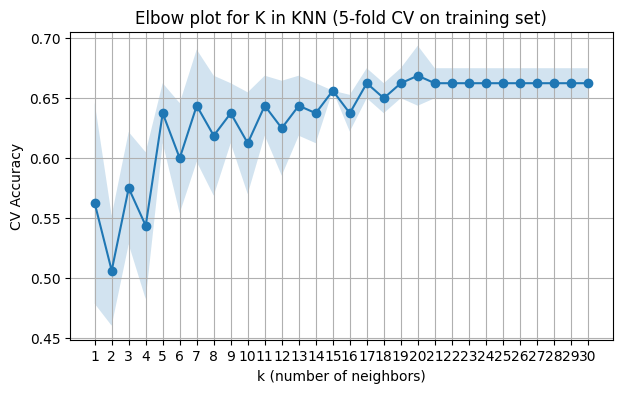

In [29]:
plt.figure(figsize=(7,4))
plt.plot(k_values, cv_means, marker="o")
plt.fill_between(k_values,
                 np.array(cv_means) - np.array(cv_stds),
                 np.array(cv_means) + np.array(cv_stds),
                 alpha=0.2)
plt.xlabel("k (number of neighbors)")
plt.ylabel("CV Accuracy")
plt.title("Elbow plot for K in KNN (5-fold CV on training set)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [30]:
# Pick k with highest mean accuracy; if tie, smallest k
best_idx = int(np.argmax(cv_means))
k_opt = k_values[best_idx]
print(f"Optimal k by CV mean accuracy: {k_opt} (mean={cv_means[best_idx]:.4f}, std={cv_stds[best_idx]:.4f})")

Optimal k by CV mean accuracy: 20 (mean=0.6687, std=0.0250)


**The best k is 20 because it yields the highest mean accuracy based on the 5-fold cross-validation.**

## **Question 3 (5 points):**
## Fit a new KNN with the optimal k and plot a confusion matrix for its performance on the test dataset using sklearn's ConfusionMatrixDisplay function.

In [31]:
# KNN model
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
knn_opt = KNeighborsClassifier(n_neighbors=k_opt)
knn_opt.fit(X_train, y_train)
y_pred = knn_opt.predict(X_test)

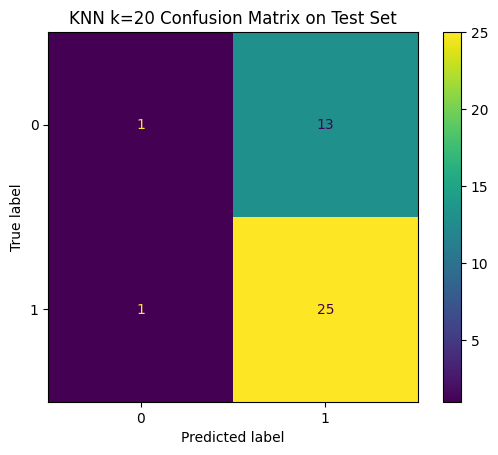

In [35]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
display_labels=[0,1])
disp.plot(values_format ="d" )
plt.title(f"KNN k={k_opt} Confusion Matrix on Test Set")
plt.show()

## In a text markdown cell, explain which mistakes are most likely according to your confusion matrix. Which digits are more likely to be confused for each other? Do you find any interesting patterns?

**The two error types are...**

## **Question 4 (10 points):**
## Perform 10-fold cross-validation on a vanilla KNN with the optimal k and compare the results of single split vs. 10-fold cross-validation by plotting accuracy (y-axis) against fold number (x-axis). Plot an additional horizontal line to mark the single split's accuracy on the plot.


In [ ]:
from sklearn.metrics import accuracy_score

# Single-split accuracy

In [ ]:
# 10-fold CV on the whole dataset (same model/params)

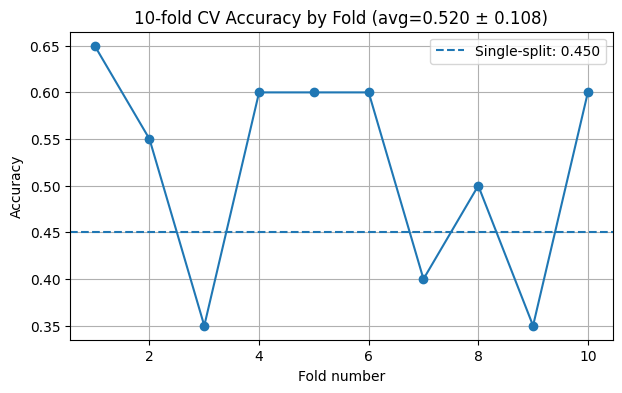

In [ ]:
# Plot with additional horizontal line

## **Question 5 (5 points):**
## Describe the effect of different fold numbers on the results of cross validation in a text markdown cell and if the results are expected. Give the average accuracy of CV scores across all folds.

## Does your plot look reasonable? Why or why not?

In [ ]:
# Average accuracy across folds

**Yes, my plot looks reasonable because...**